# camel beauty assessor — baseline detection model

| run | initialisation | dataset | isolates |
|---|---|---|---|
| `b0-scratch` | random | `detect/plain` | the floor: what 137 images give with no pretraining |
| `b1-rgb` | coco | `detect/plain` | the baseline |
| `b2-aug` | coco | `detect/rot90-rgb` | whether the four quarter turns help or hurt |
| `b3-aug-gray` | coco | `detect/rot90-gray` | the contribution of colour, measured against b2 |

## 1. setup

### 1.1 imports

In [1]:
import os
import csv
import json
import time
import shutil
import pathlib
import platform
import collections

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

try:
    import torch
    torch.rand(1).numpy()
except (ImportError, RuntimeError) as e:
    raise RuntimeError(f"torch is unusable ({e}). run: pip install -r requirements.txt") from e

import mlflow
import ultralytics
from ultralytics import YOLO, settings as yolo_settings

print(f"python {platform.python_version()}   torch {torch.__version__}")
print(f"ultralytics {ultralytics.__version__}   mlflow {mlflow.__version__}")

python 3.12.10   torch 2.14.0+cu130
ultralytics 8.4.142   mlflow 3.16.0


### 1.2 paths

In [2]:
root = pathlib.Path.cwd()

VERSION = "v2"
data = root / "dataset" / VERSION

src_rgb = data / "split" / "rgb"
src_aug = data / "augmented" / "rot90-rgb"
src_aug_gray = data / "augmented" / "rot90-gray"

det_rgb = data / "detect" / "plain"
det_aug = data / "detect" / "rot90-rgb"
det_aug_gray = data / "detect" / "rot90-gray"

project = root / "runs" / VERSION
results = root / "results" / VERSION
weights_dir = root / "weights"

results.mkdir(exist_ok=True)
weights_dir.mkdir(exist_ok=True)

### 1.3 display options

In [3]:
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

pd.set_option("display.width", 250)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 115)
pd.set_option("display.expand_frame_repr", False)

### 1.4 run configuration

In [4]:
seed = 42
splits = ["train", "val", "test"]

canon = ["Camel", "High_withers", "Large-head", "Large-lips", "Large-nose",
         "Large_hump", "Long-legs", "Long-neck", "Wide_body"]
traits = [c for c in canon if c != "Camel"]

epochs = 200
imgsz = 640
patience = 50
conf_threshold = 0.25
conf_floor = 0.01
iou_threshold = 0.5

### 1.5 device

`use_gpu` is the only value that should differ between machines.

In [5]:
use_gpu = "auto"

has_cuda = torch.cuda.is_available()
has_mps = getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available()

if use_gpu is False:
    device = "cpu"
elif has_cuda:
    device = 0
elif use_gpu is True and has_mps:
    device = "mps"
else:
    device = "cpu"

batch = 16 if device != "cpu" else 8
workers = 0 if platform.system() == "Darwin" else (8 if device != "cpu" else 2)
amp = device != "cpu"

print(f"{platform.system()} {platform.machine()}   device {device}")
print(f"batch {batch}   workers {workers}   amp {amp}")

print(f"cuda: {torch.cuda.get_device_name(0)}")

Windows AMD64   device 0
batch 16   workers 8   amp True
cuda: NVIDIA GeForce RTX 4080 SUPER


### 1.6 experiment tracking

tracking has to be on before the first run. a finished run cannot be registered afterwards.

In [6]:
tracking_uri = "sqlite:///" + (root / "mlflow.db").resolve().as_posix()
os.environ["MLFLOW_TRACKING_URI"] = tracking_uri
os.environ["MLFLOW_EXPERIMENT_NAME"] = f"camel-beauty-cv-{VERSION}"
yolo_settings.update({"mlflow": True})

mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment(f"camel-beauty-cv-{VERSION}")

print("tracking to", tracking_uri)
print(f"dashboard:  mlflow ui --backend-store-uri {tracking_uri}")

2026/09/11 16:47:39 INFO mlflow.tracking.fluent: Experiment with name 'camel-beauty-cv-v2' does not exist. Creating a new experiment.


tracking to sqlite:///E:/PycharmProjects/camel-beauty-assessor/mlflow.db
dashboard:  mlflow ui --backend-store-uri sqlite:///E:/PycharmProjects/camel-beauty-assessor/mlflow.db


## 2. helpers

### 2.1 labels

In [7]:
def cls_name(i):
    i = int(i)
    if not 0 <= i < len(canon):
        raise ValueError(f"class id {i} is outside the {len(canon)} class schema {canon}")
    return canon[i]


def read_label(path):
    rows = []
    with open(path, encoding="utf-8") as fh:
        for n, line in enumerate(fh, 1):
            if not line.strip():
                continue
            p = line.split()
            if not 0 <= int(p[0]) < len(canon):
                raise ValueError(f"{path} line {n}: class id {p[0]} is not one of the {len(canon)}")
            rows.append((int(p[0]), [float(v) for v in p[1:]]))
    return rows


def label_for(root, sp, name):
    return root / sp / "labels" / (os.path.splitext(name)[0] + ".txt")


def to_box(geo):
    if len(geo) == 4:
        xc, yc, w, h = geo
    else:
        xs, ys = geo[0::2], geo[1::2]
        x0, x1, y0, y1 = min(xs), max(xs), min(ys), max(ys)
        xc, yc, w, h = (x0 + x1) / 2, (y0 + y1) / 2, x1 - x0, y1 - y0
    return [min(max(v, 0.0), 1.0) for v in (xc, yc, w, h)]

### 2.2 geometry

In [8]:
def xywhn_to_xyxyn(box):
    xc, yc, w, h = box
    return [xc - w / 2, yc - h / 2, xc + w / 2, yc + h / 2]


def overlap(a, b):
    x0, y0 = max(a[0], b[0]), max(a[1], b[1])
    x1, y1 = min(a[2], b[2]), min(a[3], b[3])
    return max(0.0, x1 - x0) * max(0.0, y1 - y0)


def iou(a, b):
    inter = overlap(a, b)
    union = (a[2] - a[0]) * (a[3] - a[1]) + (b[2] - b[0]) * (b[3] - b[1]) - inter
    return inter / union if union > 0 else 0.0


def place(src, dst):
    try:
        os.link(src, dst)
    except (OSError, NotImplementedError, AttributeError):
        shutil.copy2(src, dst)

## 3. label repair

v2 is boxes only, so this converts nothing. `polygons_converted` reading 0 is the proof. the section
stays because a future export could reintroduce them, and the failure is silent when it happens.

In [9]:
def build_det(src_root, dst_root):
    assert (src_root / "train" / "images").is_dir(), f"{src_root} is missing, run preprocessing.ipynb first"

    shutil.rmtree(dst_root, ignore_errors=True)
    stat = collections.Counter()

    for sp in splits:
        (dst_root / sp / "images").mkdir(parents=True)
        (dst_root / sp / "labels").mkdir(parents=True)

        for name in sorted(os.listdir(src_root / sp / "images")):
            stem = os.path.splitext(name)[0]
            place(src_root / sp / "images" / name, dst_root / sp / "images" / name)

            rows = read_label(label_for(src_root, sp, name))
            stat["files"] += 1
            if {len(geo) == 4 for _, geo in rows} == {True, False}:
                stat["files_ultralytics_would_misread"] += 1

            out = []
            for cls, geo in rows:
                stat["lines"] += 1
                stat["already_boxes" if len(geo) == 4 else "polygons_converted"] += 1
                out.append(f"{cls} " + " ".join(f"{v:.6f}" for v in to_box(geo)))

            (dst_root / sp / "labels" / (stem + ".txt")).write_text("\n".join(out) + "\n", encoding="utf-8")

    (dst_root / "data.yaml").write_text(
        f"path: {dst_root.resolve().as_posix()}\n"
        "train: train/images\nval: val/images\ntest: test/images\n\n"
        f"nc: {len(canon)}\n"
        "names: [" + ", ".join(f"'{c}'" for c in canon) + "]\n",
        encoding="utf-8")

    return stat, dst_root / "data.yaml"

In [10]:
stat_rgb, data_rgb = build_det(src_rgb, det_rgb)
stat_aug, data_aug = build_det(src_aug, det_aug)
stat_aug_gray, data_aug_gray = build_det(src_aug_gray, det_aug_gray)

order = ["files", "lines", "already_boxes", "polygons_converted", "files_ultralytics_would_misread"]
repair = pd.DataFrame({"rgb": stat_rgb, "augmented": stat_aug, "augmented gray": stat_aug_gray})
repair.reindex(order).fillna(0).astype(int)

,rgb,augmented,augmented gray
files,195,606,606
lines,931,2872,2872
already_boxes,931,2872,2872
polygons_converted,0,0,0
files_ultralytics_would_misread,0,0,0


In [11]:
print(f"{stat_rgb['files_ultralytics_would_misread']} label files held boxes and polygons at once.")
print("ultralytics reads such a file entirely as polygons, so every plain box row in it would have")
print("been rebuilt from the wrong two corners, silently and with no error.")

0 label files held boxes and polygons at once.
ultralytics reads such a file entirely as polygons, so every plain box row in it would have
been rebuilt from the wrong two corners, silently and with no error.


## 4. verification

In [12]:
bad_fields, bad_range, missing = [], [], []
after, before = collections.Counter(), collections.Counter()

for dst in (det_rgb, det_aug, det_aug_gray):
    for sp in splits:
        for name in sorted(os.listdir(dst / sp / "images")):
            lp = label_for(dst, sp, name)
            if not lp.exists():
                missing.append(lp.name)
                continue
            for cls, geo in read_label(lp):
                if len(geo) != 4:
                    bad_fields.append(lp.name)
                if any(v < 0 or v > 1 for v in geo):
                    bad_range.append(lp.name)
                if dst == det_rgb:
                    after[cls_name(cls)] += 1

for sp in splits:
    for f in sorted(os.listdir(src_rgb / sp / "labels")):
        for cls, geo in read_label(src_rgb / sp / "labels" / f):
            before[cls_name(cls)] += 1

In [13]:
checks = {
    "every image has a label": not missing,
    "every label line has exactly 5 fields": not bad_fields,
    "every coordinate inside [0, 1]": not bad_range,
    "class totals unchanged by the conversion": after == before,
    "the augmented set shares the rgb val and test splits": all(
        sorted(os.listdir(det_aug / sp / "images")) == sorted(os.listdir(det_rgb / sp / "images"))
        for sp in ("val", "test")),
    "the two augmented sets differ in nothing but colour": all(
        (det_aug / sp / "labels" / f).read_text(encoding="utf-8")
        == (det_aug_gray / sp / "labels" / f).read_text(encoding="utf-8")
        for sp in splits for f in os.listdir(det_aug / sp / "labels")),
}

for k, v in checks.items():
    print(f"  {'PASS' if v else 'FAIL'}  {k}")
assert all(checks.values()), "a verification check failed"

  PASS  every image has a label
  PASS  every label line has exactly 5 fields
  PASS  every coordinate inside [0, 1]
  PASS  class totals unchanged by the conversion
  PASS  the augmented set shares the rgb val and test splits
  PASS  the two augmented sets differ in nothing but colour


In [14]:
pd.DataFrame([{"dataset": label, "split": sp,
               "images": len(os.listdir(d / sp / "images")),
               "boxes": sum(len(read_label(d / sp / "labels" / f))
                            for f in os.listdir(d / sp / "labels"))}
              for d, label in ((det_rgb, "rgb"), (det_aug, "aug"), (det_aug_gray, "aug gray"))
              for sp in splits]).pivot(index="split", columns="dataset",
                                       values=["images", "boxes"]).reindex(splits)

images               boxes              
dataset    aug aug gray  rgb   aug aug gray  rgb
split                                           
train      548      548  137  2588     2588  647
val         30       30   30   144      144  144
test        28       28   28   140      140  140

## 5. annotation scale

under roughly 32px on the shortest side is a small object, and the first thing a detector misses.

In [15]:
rows, sizes = [], []
for sp in splits:
    for name in sorted(os.listdir(det_rgb / sp / "images")):
        sizes.append(Image.open(det_rgb / sp / "images" / name).size)
        for cls, (xc, yc, w, h) in read_label(label_for(det_rgb, sp, name)):
            rows.append({"cls": cls_name(cls), "w": w, "h": h})

print("native image resolution")
pd.DataFrame(sizes, columns=["width", "height"]).describe().loc[["min", "50%", "max"]].astype(int)

native image resolution


,width,height
min,297,200
50%,727,800
max,1504,1600


In [16]:
boxes = pd.DataFrame(rows)
size = boxes.groupby("cls")[["w", "h"]].median().round(4)
size["boxes"] = boxes.groupby("cls").size()
size["area_pct"] = (size.w * size.h * 100).round(2)
for px in (640, 960, 1280):
    size[f"px_at_{px}"] = (size[["w", "h"]].min(axis=1) * px).round().astype(int)

print("shortest side of the median box once letterboxed, and the share of frame it occupies")
size.reindex(canon).sort_values("px_at_640")

shortest side of the median box once letterboxed, and the share of frame it occupies


,w,h,boxes,area_pct,px_at_640,px_at_960,px_at_1280
cls,,,,,,,
Wide_body,0.2886,0.0432,97,1.25,28,41,55
Large-lips,0.0489,0.0536,95,0.26,31,47,63
Large-nose,0.0681,0.0490,85,0.33,31,47,63
High_withers,0.1389,0.1012,92,1.41,65,97,130
Large-head,0.1840,0.1356,58,2.50,87,130,174
Long-legs,0.1469,0.4382,103,6.44,94,141,188
Large_hump,0.2002,0.1574,91,3.15,101,151,201
Long-neck,0.2068,0.2121,115,4.39,132,199,265
Camel,0.8333,0.7040,195,58.66,451,676,901


## 6. augmentation

the quarter turns are already on disk from `preprocessing.ipynb`. everything below is applied by
ultralytics at load time, to the training split alone.

In [17]:
pd.DataFrame([
    ("hsv_h", 0.015, "nudges hue, so coat colour is not read as a trait"),
    ("hsv_s", 0.700, "swings saturation, so a washed out broadcast frame still reads"),
    ("hsv_v", 0.400, "swings brightness, covering a night runway against full daylight"),
    ("translate", 0.100, "slides the frame, so the camel is not expected dead centre"),
    ("scale", 0.500, "zooms, the main defence against a camel filling or barely filling the frame"),
    ("fliplr", 0.500, "mirrors. safe here: no left/right classes and no keypoints"),
    ("flipud", 0.000, "off. the 180 degree copy on disk combined with fliplr already reaches it"),
    ("degrees", 0.000, "off, and deliberately so. rotation is done on disk in exact quarter turns"),
    ("mosaic", 1.000, "stitches four images into one. shrinks every object, wrong way for the 32px classes"),
    ("close_mosaic", 10, "drops mosaic for the last 10 epochs so training ends on full size images"),
    ("mixup", 0.000, "off. blending two camels makes a trait box meaningless"),
    ("erasing", 0.000, "off. it applies to classification heads, not detection"),
], columns=["param", "value", "effect"])

,param,value,effect
0,hsv_h,0.015,"nudges hue, so coat colour is not read as a trait"
1,hsv_s,0.700,"swings saturation, so a washed out broadcast frame still reads"
2,hsv_v,0.400,"swings brightness, covering a night runway against full daylight"
3,translate,0.100,"slides the frame, so the camel is not expected dead centre"
4,scale,0.500,"zooms, the main defence against a camel filling or barely filling the frame"
5,fliplr,0.500,mirrors. safe here: no left/right classes and no keypoints
6,flipud,0.000,off. the 180 degree copy on disk combined with fliplr already reaches it
7,degrees,0.000,"off, and deliberately so. rotation is done on disk in exact quarter turns"
8,mosaic,1.000,"stitches four images into one. shrinks every object, wrong way for the 32px classes"
9,close_mosaic,10.000,drops mosaic for the last 10 epochs so training ends on full size images


## 7. training runs

In [18]:
def train_run(name, data, weights, init):
    os.environ["MLFLOW_RUN"] = name
    started = time.time()

    # a bare .pt name is downloaded on first use; handing over a path lands it in weights/
    model = YOLO(str(weights_dir / weights) if weights.endswith(".pt") else weights)
    model.train(data=str(data), project=str(project), name=name, exist_ok=True,
                epochs=epochs, imgsz=imgsz, batch=batch, device=device, workers=workers,
                seed=seed, deterministic=True, amp=amp, patience=patience, plots=True)

    return {"run": name, "init": init, "dataset": pathlib.Path(data).parent.name, "weights": weights,
            "best": str(project / name / "weights" / "best.pt"),
            "epochs": epochs, "imgsz": imgsz, "batch": batch, "device": str(device),
            "minutes": round((time.time() - started) / 60, 1)}

In [19]:
def evaluate(rec, data, split="test"):
    model = YOLO(rec["best"])
    m = model.val(data=str(data), split=split, imgsz=imgsz, batch=batch, device=device,
                  project=str(project), name=f"{rec['run']}-{split}", exist_ok=True, plots=True)

    rec = dict(rec)
    rec.update({"split": split,
                "mAP50": round(float(m.box.map50), 4),
                "mAP50_95": round(float(m.box.map), 4),
                "precision": round(float(m.box.mp), 4),
                "recall": round(float(m.box.mr), 4),
                "val_dir": str(m.save_dir)})
    return rec, m


def per_class(m):
    rows = []
    for i, c in enumerate(list(m.box.ap_class_index)):
        p, r, ap50, ap = m.box.class_result(i)
        rows.append({"cls": cls_name(c), "precision": round(float(p), 3), "recall": round(float(r), 3),
                     "mAP50": round(float(ap50), 3), "mAP50_95": round(float(ap), 3)})
    return pd.DataFrame(rows).set_index("cls").reindex(canon)

In [20]:
b0 = train_run("b0-scratch", data_rgb, "yolo11n.yaml", "random")
b0

New https://pypi.org/project/ultralytics/8.4.147 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.142  Python-3.12.10 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\PycharmProjects\camel-beauty-assessor\dataset\v2\detect\plain\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01

{'run': 'b0-scratch',
 'init': 'random',
 'dataset': 'plain',
 'weights': 'yolo11n.yaml',
 'best': 'E:\\PycharmProjects\\camel-beauty-assessor\\runs\\v2\\b0-scratch\\weights\\best.pt',
 'epochs': 200,
 'imgsz': 640,
 'batch': 16,
 'device': '0',
 'minutes': 8.3}

In [21]:
b1 = train_run("b1-rgb", data_rgb, "yolo11n.pt", "coco")
b1

New https://pypi.org/project/ultralytics/8.4.147 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.142  Python-3.12.10 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\PycharmProjects\camel-beauty-assessor\dataset\v2\detect\plain\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01

{'run': 'b1-rgb',
 'init': 'coco',
 'dataset': 'plain',
 'weights': 'yolo11n.pt',
 'best': 'E:\\PycharmProjects\\camel-beauty-assessor\\runs\\v2\\b1-rgb\\weights\\best.pt',
 'epochs': 200,
 'imgsz': 640,
 'batch': 16,
 'device': '0',
 'minutes': 7.7}

In [22]:
b2 = train_run("b2-aug", data_aug, "yolo11n.pt", "coco")
b2

New https://pypi.org/project/ultralytics/8.4.147 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.142  Python-3.12.10 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\PycharmProjects\camel-beauty-assessor\dataset\v2\detect\rot90-rgb\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=

{'run': 'b2-aug',
 'init': 'coco',
 'dataset': 'rot90-rgb',
 'weights': 'yolo11n.pt',
 'best': 'E:\\PycharmProjects\\camel-beauty-assessor\\runs\\v2\\b2-aug\\weights\\best.pt',
 'epochs': 200,
 'imgsz': 640,
 'batch': 16,
 'device': '0',
 'minutes': 13.3}

In [23]:
b3 = train_run("b3-aug-gray", data_aug_gray, "yolo11n.pt", "coco")
b3

New https://pypi.org/project/ultralytics/8.4.147 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.142  Python-3.12.10 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\PycharmProjects\camel-beauty-assessor\dataset\v2\detect\rot90-gray\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf

{'run': 'b3-aug-gray',
 'init': 'coco',
 'dataset': 'rot90-gray',
 'weights': 'yolo11n.pt',
 'best': 'E:\\PycharmProjects\\camel-beauty-assessor\\runs\\v2\\b3-aug-gray\\weights\\best.pt',
 'epochs': 200,
 'imgsz': 640,
 'batch': 16,
 'device': '0',
 'minutes': 16.0}

## 8. training batch inspection

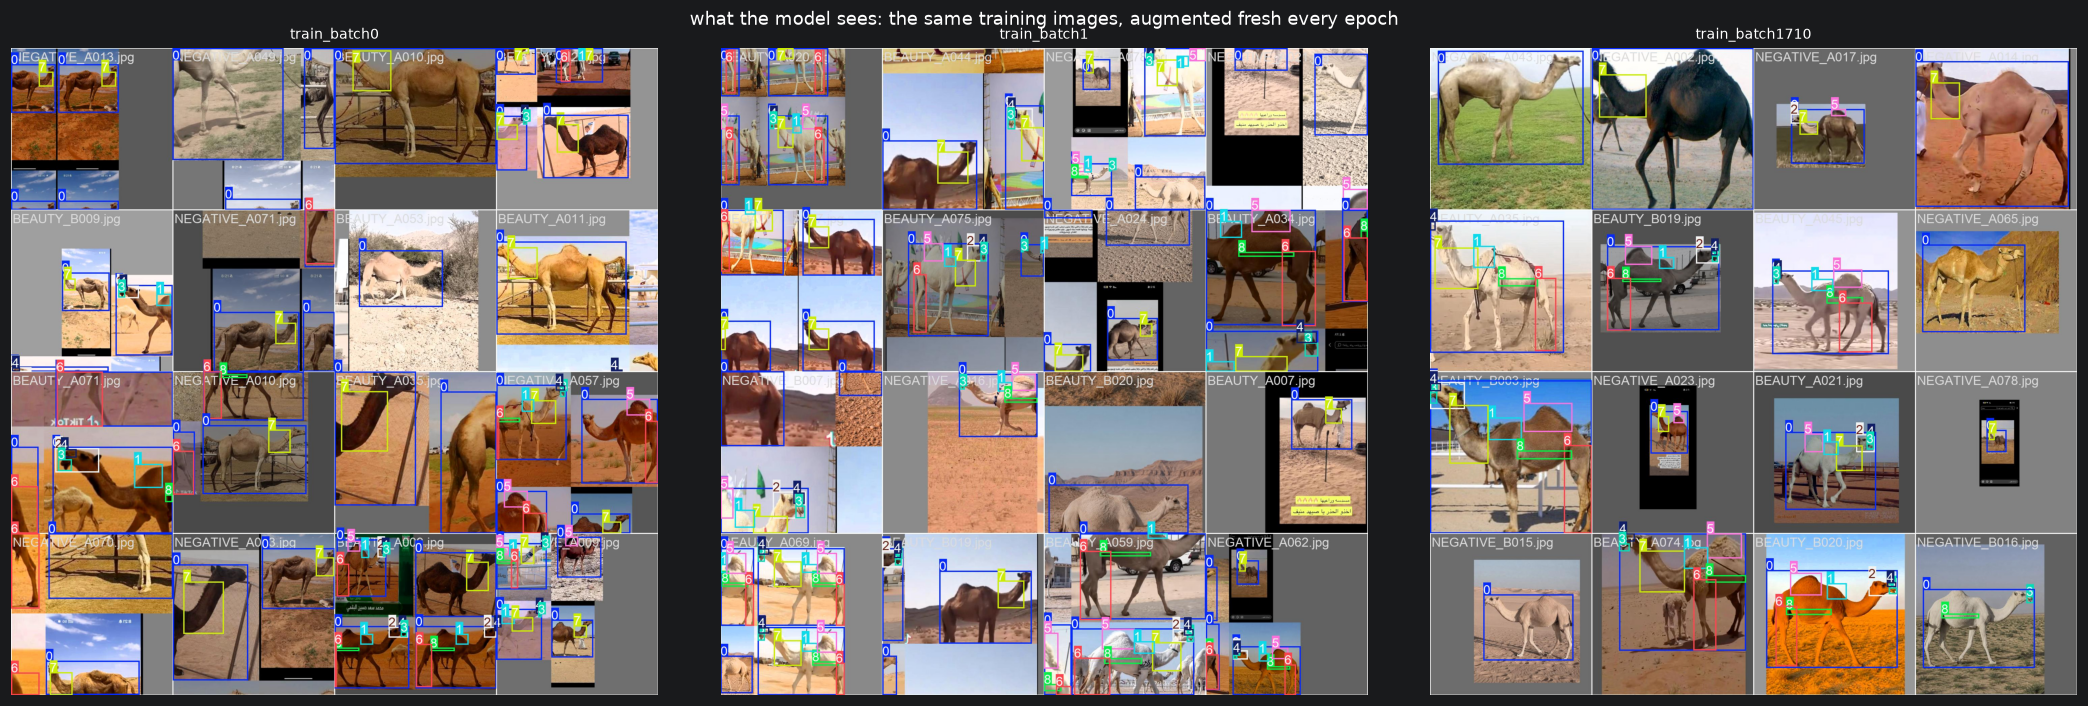

In [24]:
shots = sorted((project / b1["run"]).glob("train_batch*.jpg"))[:3]
if not shots:
    print("no training batch previews found, training may not have run yet")
else:
    fig, axes = plt.subplots(1, len(shots), figsize=(6.5 * len(shots), 6.5))
    for ax, p in zip(np.atleast_1d(axes), shots):
        ax.imshow(Image.open(p))
        ax.set_title(p.stem, fontsize=9)
        ax.axis("off")
    fig.suptitle("what the model sees: the same training images, augmented fresh every epoch")
    plt.tight_layout()
    plt.show()

## 9. learning curves

In [25]:
def history(rec):
    path = pathlib.Path(rec["best"]).parents[1] / "results.csv"
    if not path.exists():
        return None
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    return df


def loss_pair(df):
    train = df[[c for c in df.columns if c.startswith("train/") and c.endswith("_loss")]].sum(axis=1)
    val = df[[c for c in df.columns if c.startswith("val/") and c.endswith("_loss")]].sum(axis=1)
    return train, val


def map_col(df):
    return next(c for c in df.columns if "mAP50-95" in c)


trained = [r for r in (b0, b1, b2, b3) if history(r) is not None]
assert trained, "no results.csv found, run section 7 first"

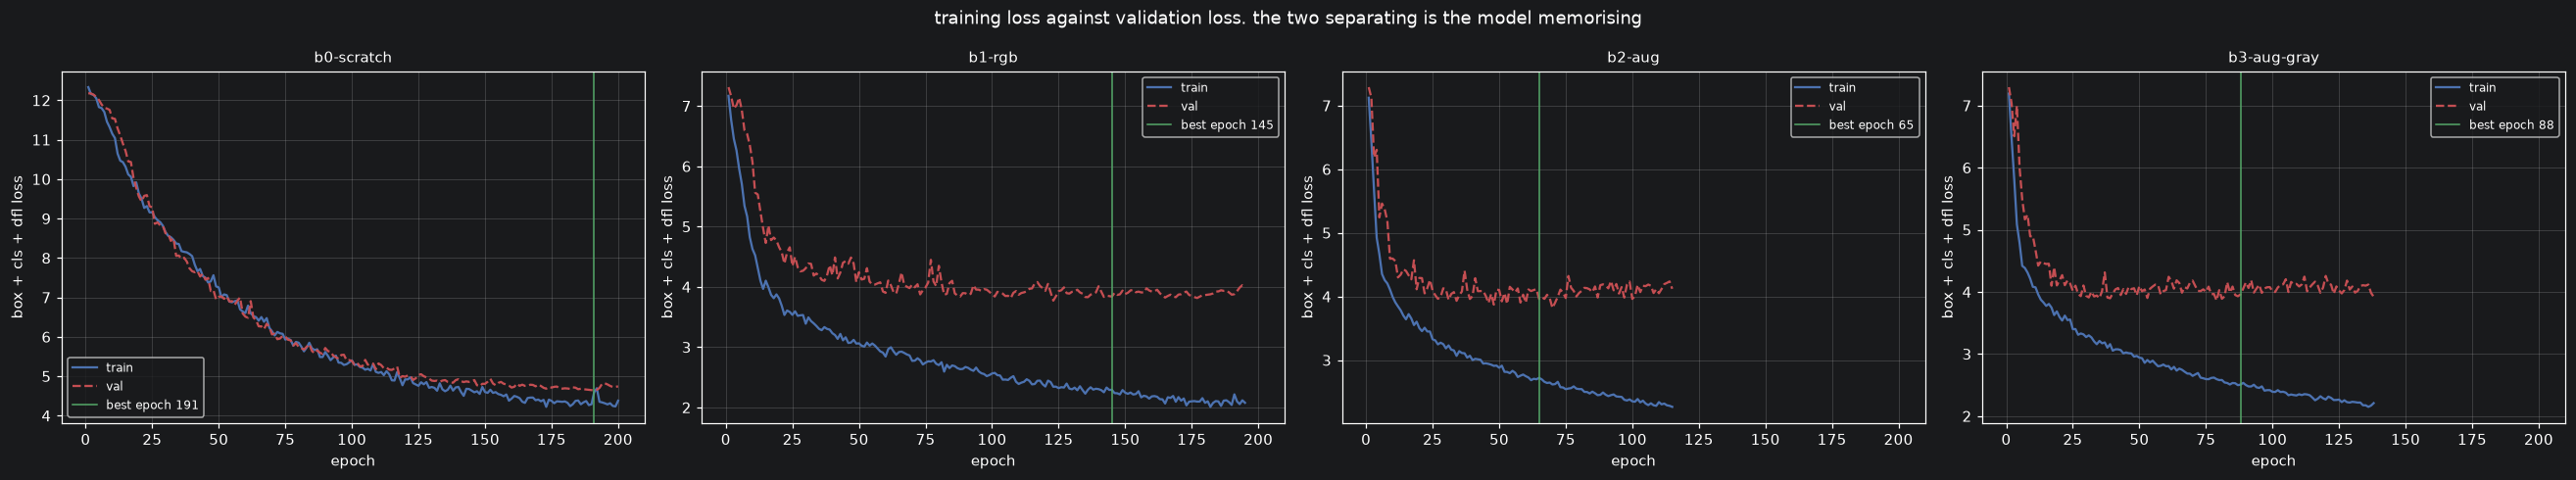

In [26]:
fig, axes = plt.subplots(1, len(trained), figsize=(6 * len(trained), 4.5), sharex=True)
for ax, rec in zip(np.atleast_1d(axes), trained):
    df = history(rec)
    train, val = loss_pair(df)
    best_epoch = int(df.epoch.iloc[df[map_col(df)].values.argmax()])

    ax.plot(df.epoch, train, label="train", color="#4c72b0")
    ax.plot(df.epoch, val, label="val", color="#c44e52", linestyle="--")
    ax.axvline(best_epoch, color="#55a868", lw=1, label=f"best epoch {best_epoch}")
    ax.set_title(rec["run"], fontsize=10)
    ax.set_xlabel("epoch")
    ax.set_ylabel("box + cls + dfl loss")
    ax.legend(fontsize=8)

fig.suptitle("training loss against validation loss. the two separating is the model memorising")
plt.tight_layout()
plt.show()

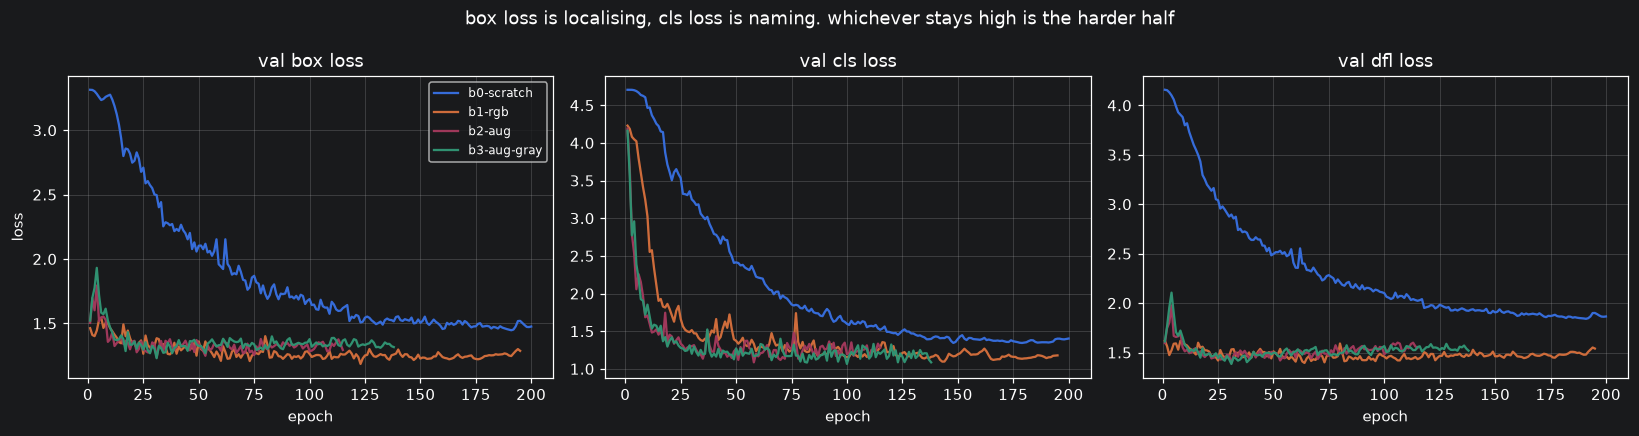

In [27]:
parts = ["box_loss", "cls_loss", "dfl_loss"]
fig, axes = plt.subplots(1, len(parts), figsize=(5 * len(parts), 4))
for ax, part in zip(axes, parts):
    for rec in trained:
        df = history(rec)
        if f"val/{part}" in df.columns:
            ax.plot(df.epoch, df[f"val/{part}"], label=rec["run"])
    ax.set_title(f"val {part.replace('_', ' ')}")
    ax.set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].legend(fontsize=8)
fig.suptitle("box loss is localising, cls loss is naming. whichever stays high is the harder half")
plt.tight_layout()
plt.show()

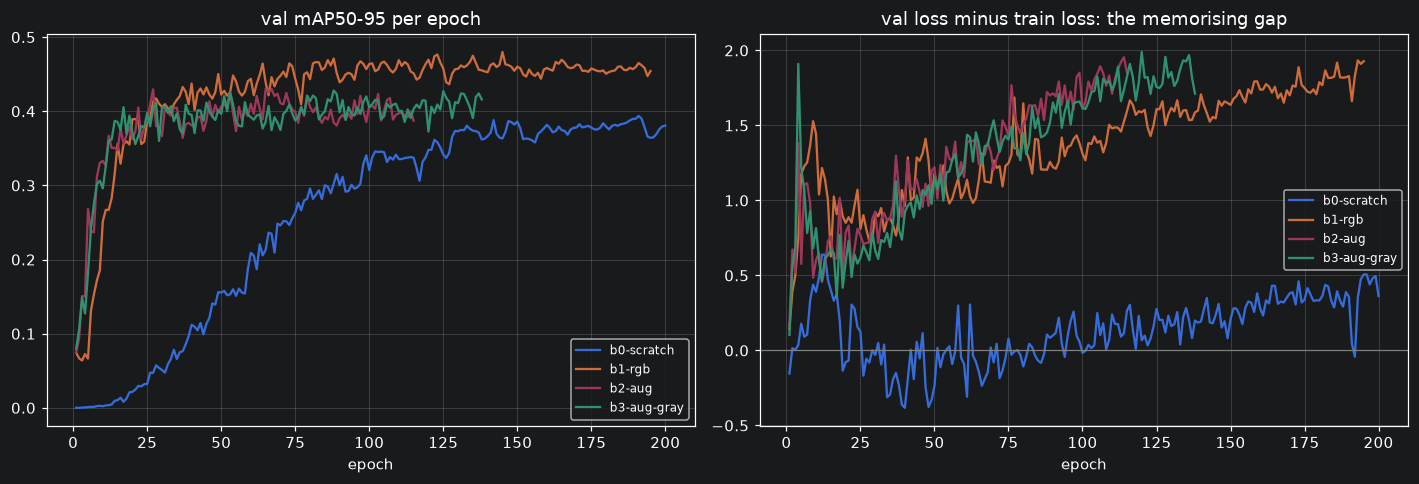

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for rec in trained:
    df = history(rec)
    train, val = loss_pair(df)
    axes[0].plot(df.epoch, df[map_col(df)], label=rec["run"])
    axes[1].plot(df.epoch, val - train, label=rec["run"])

axes[0].set_title("val mAP50-95 per epoch")
axes[1].set_title("val loss minus train loss: the memorising gap")
axes[1].axhline(0, color="grey", lw=0.8)
for ax in axes:
    ax.set_xlabel("epoch")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [29]:
rows = []
for rec in trained:
    df = history(rec)
    train, val = loss_pair(df)
    pos = int(df[map_col(df)].values.argmax())
    rows.append({"run": rec["run"],
                 "epochs_run": int(df.epoch.max()),
                 "best_epoch": int(df.epoch.iloc[pos]),
                 "best_val_mAP50_95": round(float(df[map_col(df)].max()), 4),
                 "train_loss_start": round(float(train.iloc[0]), 3),
                 "train_loss_end": round(float(train.iloc[-1]), 3),
                 "val_loss_best": round(float(val.min()), 3),
                 "val_loss_end": round(float(val.iloc[-1]), 3)})

curves = pd.DataFrame(rows).set_index("run")
curves["gap"] = (curves.val_loss_end - curves.train_loss_end).round(3)
curves["val_rebound"] = (curves.val_loss_end - curves.val_loss_best).round(3)

print(f"epochs_run under {epochs} means early stopping fired after {patience} epochs without gain")
print("val_rebound above zero means val loss bottomed out and then climbed: the model started")
print("memorising. best.pt is saved at best_epoch, so the final weights are not the harmed ones.")
curves

epochs_run under 200 means early stopping fired after 50 epochs without gain
val_rebound above zero means val loss bottomed out and then climbed: the model started
memorising. best.pt is saved at best_epoch, so the final weights are not the harmed ones.


,epochs_run,best_epoch,best_val_mAP50_95,train_loss_start,train_loss_end,val_loss_best,val_loss_end,gap,val_rebound
run,,,,,,,,,
b0-scratch,200,191,0.3938,12.332,4.379,4.637,4.742,0.363,0.105
b1-rgb,195,145,0.4800,7.168,2.077,3.772,4.005,1.928,0.233
b2-aug,115,65,0.4303,7.123,2.266,3.820,4.121,1.855,0.301
b3-aug-gray,138,88,0.4280,7.192,2.208,3.862,3.921,1.713,0.059


## 10. results

In [30]:
b0_test, m0 = evaluate(b0, data_rgb)
b1_test, m1 = evaluate(b1, data_rgb)
b2_test, m2 = evaluate(b2, data_aug)
b3_test, m3 = evaluate(b3, data_aug_gray)

runs = [b0_test, b1_test, b2_test, b3_test]
compare = pd.DataFrame(runs)[
    ["run", "init", "dataset", "minutes", "mAP50", "mAP50_95", "precision", "recall"]].set_index("run")

print(f"held out test split: {len(os.listdir(det_rgb / 'test' / 'images'))} images")
compare

Ultralytics 8.4.142  Python-3.12.10 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
YOLO11n summary (fused): 100 layers, 2,583,907 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 416.6238.2 MB/s, size: 41.3 KB)
val: Scanning E:\PycharmProjects\camel-beauty-assessor\dataset\v2\detect\plain\test\labels... 28 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 28/28 2.5Kit/s 0.0s
val: New cache created: E:\PycharmProjects\camel-beauty-assessor\dataset\v2\detect\plain\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.0it/s 2.0s5.9s
                   all         28        140      0.651      0.564      0.604       0.32
                 Camel         28         28      0.901          1       0.99      0.753
          High_withers         13         13      0.567      0.538      0.685      0.276
            Large-head          9          9      0.709      

,init,dataset,minutes,mAP50,mAP50_95,precision,recall
run,,,,,,,
b0-scratch,random,plain,8.3,0.6045,0.3199,0.6512,0.5645
b1-rgb,coco,plain,7.7,0.7983,0.4384,0.7546,0.7915
b2-aug,coco,rot90-rgb,13.3,0.6664,0.3747,0.7186,0.5852
b3-aug-gray,coco,rot90-gray,16.0,0.7650,0.4164,0.7169,0.7484


In [31]:
deltas = pd.Series({
    "pretraining (b1 - b0)": b1_test["mAP50_95"] - b0_test["mAP50_95"],
    "rotation (b2 - b1)": b2_test["mAP50_95"] - b1_test["mAP50_95"],
    "dropping colour (b3 - b2)": b3_test["mAP50_95"] - b2_test["mAP50_95"],
}).round(4)

print("each row moves one factor and holds the rest, in mAP50-95 on the same test split")
print("a negative number is a real result, not a failed run")
deltas

each row moves one factor and holds the rest, in mAP50-95 on the same test split
a negative number is a real result, not a failed run


pretraining (b1 - b0)        0.1185
rotation (b2 - b1)          -0.0637
dropping colour (b3 - b2)    0.0417
dtype: float64

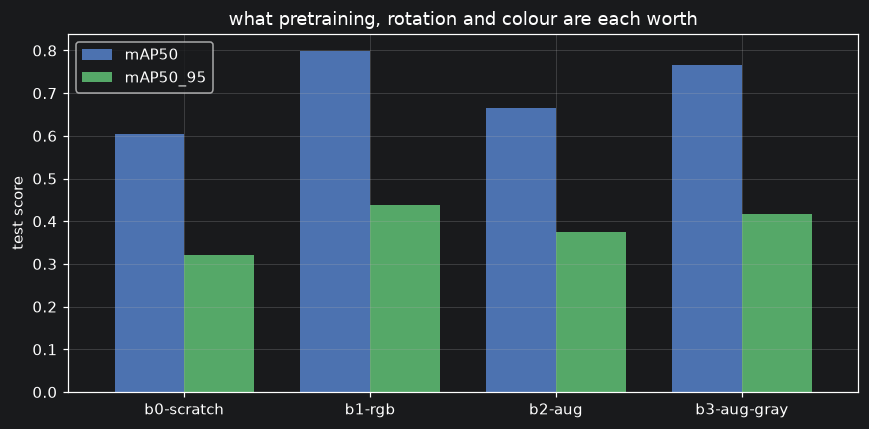

In [32]:
fig, ax = plt.subplots(figsize=(8, 4))
compare[["mAP50", "mAP50_95"]].plot(kind="bar", ax=ax, color=["#4c72b0", "#55a868"], width=0.75)
ax.set_ylabel("test score")
ax.set_xlabel("")
ax.set_title("what pretraining, rotation and colour are each worth")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 10.1 per-class performance

a score resting on ten boxes is not an estimate, so the box count is printed beside it.

In [33]:
pc = pd.concat({"baseline": per_class(m1), "augmented": per_class(m2),
                "augmented gray": per_class(m3)}, axis=1)
pc["boxes_in_test"] = [sum(1 for f in os.listdir(det_rgb / "test" / "labels")
                           for cls, _ in read_label(det_rgb / "test" / "labels" / f)
                           if cls_name(cls) == c) for c in canon]

pc

baseline                        augmented                        augmented gray                        boxes_in_test
             precision recall  mAP50 mAP50_95 precision recall  mAP50 mAP50_95      precision recall  mAP50 mAP50_95              
cls                                                                                                                               
Camel            0.934  1.000  0.995    0.787     0.940  0.964  0.963    0.745          0.990  1.000  0.995    0.842            28
High_withers     0.783  0.923  0.869    0.413     0.601  0.811  0.786    0.350          0.662  0.846  0.856    0.356            13
Large-head       0.655  0.634  0.657    0.425     0.647  0.209  0.495    0.321          0.657  0.778  0.736    0.469             9
Large-lips       0.619  0.786  0.884    0.403     0.876  0.505  0.744    0.344          0.802  0.929  0.886    0.367            14
Large-nose       0.821  0.692  0.708    0.347     0.757  0.482  0.546    0.294          0.860  0.769  0.835    0.434            13
Large_hump       0.760  0.846  0.843    0.425     0.704  0.692  0.736    0.446          0.721  0.599  0.808    0.406            13
Long-legs        0.732  0.812  0.843    0.365     0.558  0.562  0.589    0.269          0.641  0.875  0.665    0.267            16
Long-neck        0.935  0.857  0.948    0.607     0.859  0.810  0.902    0.521          0.832  0.709  0.779    0.472            21
Wide_body        0.553  0.572  0.438    0.174     0.525  0.231  0.237    0.083          0.286  0.231  0.326    0.135            13

### 10.2 confusion matrix and precision-recall curves

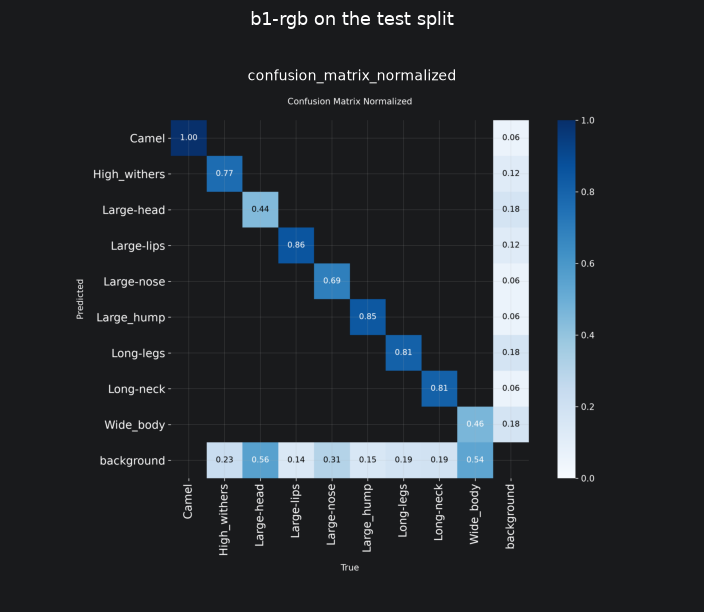

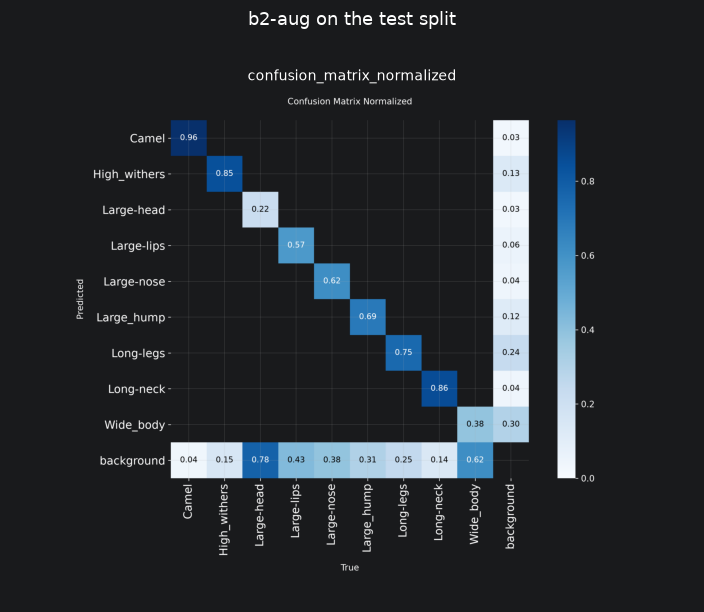

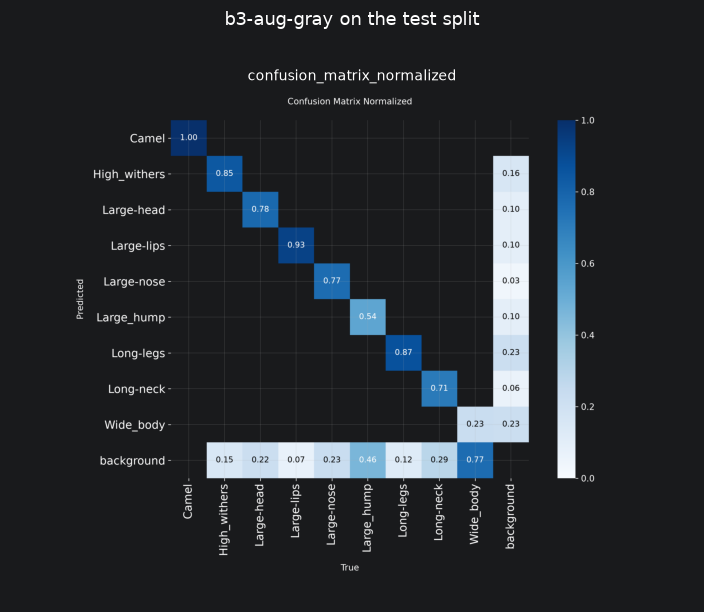

In [34]:
for rec in (b1_test, b2_test, b3_test):
    d = pathlib.Path(rec["val_dir"])
    shown = [f for f in ("confusion_matrix_normalized.png", "PR_curve.png", "R_curve.png") if (d / f).exists()]
    if not shown:
        continue
    fig, axes = plt.subplots(1, len(shown), figsize=(6.5 * len(shown), 6))
    for ax, f in zip(np.atleast_1d(axes), shown):
        ax.imshow(Image.open(d / f))
        ax.set_title(f[:-4], fontsize=9)
        ax.axis("off")
    fig.suptitle(f"{rec['run']} on the test split")
    plt.tight_layout()
    plt.show()

## 11. error analysis

In [35]:
def match(pred, gt):
    used, tp, fp, wrong = set(), 0, 0, []
    for cls, conf, box in pred:
        best, hit = 0.0, None
        for i, (gc, gb) in enumerate(gt):
            if i in used or gc != cls:
                continue
            v = iou(box, gb)
            if v > best:
                best, hit = v, i
        if best >= iou_threshold:
            used.add(hit)
            tp += 1
        else:
            fp += 1
            wrong.append({"fault": "false positive", "cls": cls_name(cls), "conf": round(conf, 3)})

    for i, (gc, _) in enumerate(gt):
        if i not in used:
            wrong.append({"fault": "missed", "cls": cls_name(gc), "conf": None})
    return tp, fp, wrong

In [36]:
def analyse(rec, det_root):
    model = YOLO(rec["best"])
    image_dir = det_root / "test" / "images"
    per_image, faults = [], []

    for name in sorted(os.listdir(image_dir)):
        gt = [(cls, xywhn_to_xyxyn(geo))
              for cls, geo in read_label(label_for(det_root, "test", name))]

        r = model.predict(str(image_dir / name), conf=conf_threshold, imgsz=imgsz,
                          device=device, verbose=False)[0]
        pred = sorted(((int(c), float(f), b) for c, f, b in
                       zip(r.boxes.cls.int().tolist(), r.boxes.conf.tolist(), r.boxes.xyxyn.tolist())),
                      key=lambda d: -d[1])

        tp, fp, wrong = match(pred, gt)
        faults += [{"run": rec["run"], "image": name, **w} for w in wrong]
        per_image.append({"run": rec["run"], "image": name, "boxes": len(gt),
                          "tp": tp, "fp": fp, "fn": len(gt) - tp})

    return pd.DataFrame(per_image), pd.DataFrame(faults)

In [37]:
img1, fault1 = analyse(b1_test, det_rgb)
img2, fault2 = analyse(b2_test, det_aug)

errors = pd.concat([fault1, fault2], ignore_index=True)
print("a miss means the trait was annotated and not found; a false positive means the model")
print("called a trait the annotator did not draw")
(errors.groupby(["cls", "fault", "run"]).size().unstack(["fault", "run"], fill_value=0)
 .reindex(canon).fillna(0).astype(int))

a miss means the trait was annotated and not found; a false positive means the model
called a trait the annotator did not draw


fault        false positive        missed       
run                  b1-rgb b2-aug b2-aug b1-rgb
cls                                             
Camel                     3      4      2      0
High_withers              4     10      2      2
Large-head                4      1      7      5
Large-lips                3      2      6      2
Large-nose                1      2      6      5
Large_hump                4      6      3      3
Long-legs                 3     15      4      5
Long-neck                 4      3      4      4
Wide_body                 5     18      8      7

In [38]:
ranked = img1.assign(wrong=img1.fp + img1.fn).sort_values(["wrong", "boxes"], ascending=[False, False])
print(f"{int(ranked.head(5).wrong.sum())} of {int(ranked.wrong.sum())} mistakes sit in the 5 worst images")
pd.concat([ranked.head(5), ranked.tail(3)])[["image", "boxes", "tp", "fp", "fn"]].set_index("image")

28 of 64 mistakes sit in the 5 worst images


,boxes,tp,fp,fn
image,,,,
BEAUTY_A004.jpg,7,4,4,3
BEAUTY_A036.jpg,8,2,0,6
BEAUTY_A015.jpg,9,8,4,1
BEAUTY_B005.jpg,6,5,4,1
BEAUTY_A012.jpg,5,1,1,4
NEGATIVE_A073.jpg,2,2,0,0
NEGATIVE_B014.jpg,2,2,0,0
NEGATIVE_A059.jpg,1,1,0,0


In [39]:
def draw(ax, det_root, name, boxes, title):
    img = Image.open(det_root / "test" / "images" / name).convert("RGB")
    w, h = img.size
    ax.imshow(img)
    for cls, conf, box in boxes:
        x0, y0, x1, y1 = box[0] * w, box[1] * h, box[2] * w, box[3] * h
        colour = plt.cm.tab10.colors[cls % 10]
        ax.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, lw=1.4, edgecolor=colour))
        tag = cls_name(cls) if conf is None else f"{cls_name(cls)} {conf:.2f}"
        ax.text(x0, y0 - 4, tag, fontsize=6.5, color="white",
                bbox=dict(facecolor=colour, pad=1, edgecolor="none"))
    ax.set_title(title, fontsize=8)
    ax.axis("off")
    ax.grid(False)

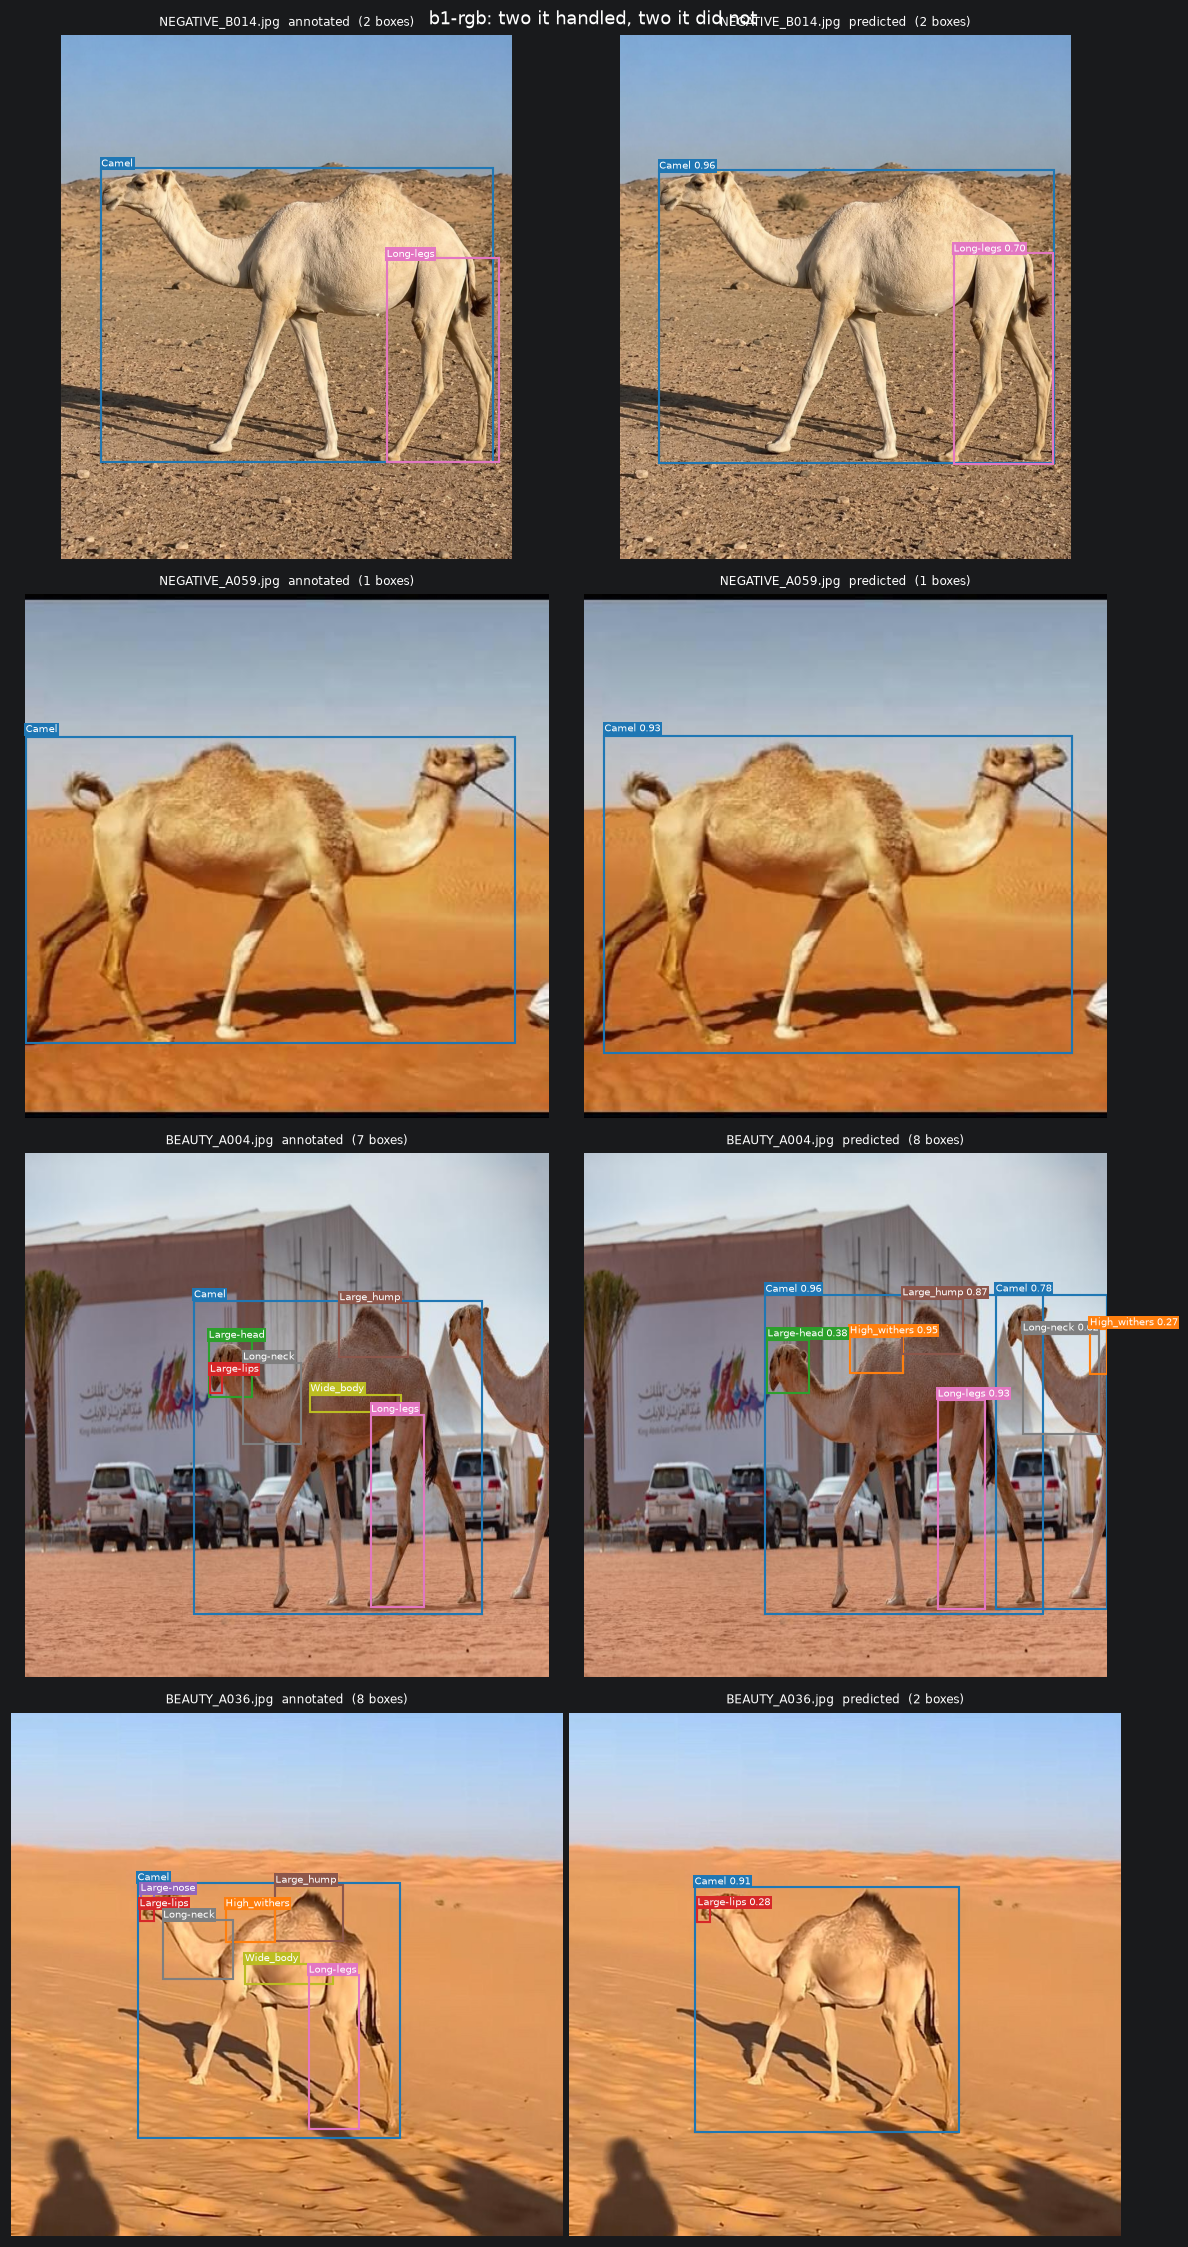

In [40]:
def compare_gt_pred(rec, det_root, names):
    model = YOLO(rec["best"])
    fig, axes = plt.subplots(len(names), 2, figsize=(11, 5.2 * len(names)))
    for row, name in zip(np.atleast_2d(axes), names):
        gt = [(cls, None, xywhn_to_xyxyn(geo))
              for cls, geo in read_label(label_for(det_root, "test", name))]
        r = model.predict(str(det_root / "test" / "images" / name), conf=conf_threshold,
                          imgsz=imgsz, device=device, verbose=False)[0]
        pred = [(int(c), float(f), b) for c, f, b in
                zip(r.boxes.cls.int().tolist(), r.boxes.conf.tolist(), r.boxes.xyxyn.tolist())]
        draw(row[0], det_root, name, gt, f"{name}  annotated  ({len(gt)} boxes)")
        draw(row[1], det_root, name, pred, f"{name}  predicted  ({len(pred)} boxes)")
    fig.suptitle(f"{rec['run']}: two it handled, two it did not")
    plt.tight_layout()
    plt.show()


compare_gt_pred(b1_test, det_rgb, list(ranked.tail(2).image) + list(ranked.head(2).image))

## 12. structured output for the language model

every trait is reported with its confidence, including the ones the detector did not find, which
score 0.0. nothing is filtered out, so the backend receives a fixed set of eight numbers per camel
and decides for itself how to combine and rank them.

one camel per image, so there is no per-camel list and no containment rule.

In [41]:
def best_per_class(dets):
    top = {}
    for cls, conf, box in dets:
        name = cls_name(cls)
        if conf > top.get(name, (0.0, None))[0]:
            top[name] = (conf, box)
    return top


def area_of(box):
    return round((box[2] - box[0]) * (box[3] - box[1]), 5)

In [42]:
def payload(model, det_root, name, run_name):
    started = time.perf_counter()
    r = model.predict(str(det_root / "test" / "images" / name), conf=conf_floor,
                      imgsz=imgsz, device=device, verbose=False)[0]
    cv_ms = round((time.perf_counter() - started) * 1000, 1)

    dets = [(int(c), round(float(f), 4), [round(float(v), 4) for v in b])
            for c, f, b in zip(r.boxes.cls.int().tolist(), r.boxes.conf.tolist(), r.boxes.xyxyn.tolist())]
    top = best_per_class(dets)

    camel_conf, camel_box = top.get("Camel", (0.0, None))
    reported = {}
    for t in traits:
        conf, box = top.get(t, (0.0, None))
        reported[t] = {"confidence": conf, "box_xyxyn": box,
                       "box_area": area_of(box) if box else 0.0}

    return {
        "image": name,
        "model": run_name,
        "cv_ms": cv_ms,
        "camel": {"confidence": camel_conf, "box_xyxyn": camel_box},
        "traits": reported,
        "trait_score": round(sum(v["confidence"] for v in reported.values()), 4),
        "traits_found": sorted([t for t, v in reported.items() if v["confidence"] > 0],
                               key=lambda t: -reported[t]["confidence"]),
        "note": "all eight traits are always present. 0.0 means the detector found nothing for it.",
    }

In [43]:
best = max(runs, key=lambda r: r["mAP50_95"])
best_root = {"b0-scratch": det_rgb, "b1-rgb": det_rgb,
             "b2-aug": det_aug, "b3-aug-gray": det_aug_gray}[best["run"]]
model = YOLO(best["best"])

payloads = [payload(model, best_root, n, best["run"])
            for n in sorted(os.listdir(best_root / "test" / "images"))]
(results / "test_predictions.json").write_text(json.dumps(payloads, indent=2), encoding="utf-8")

print(f"best on test: {best['run']}   mAP50 {best['mAP50']}   mAP50-95 {best['mAP50_95']}")
print(f"{len(payloads)} payloads written to {results / 'test_predictions.json'}")
print()
print(json.dumps(payloads[0], indent=2))

best on test: b1-rgb   mAP50 0.7983   mAP50-95 0.4384
28 payloads written to E:\PycharmProjects\camel-beauty-assessor\results\v2\test_predictions.json

{
  "image": "BEAUTY_A004.jpg",
  "model": "b1-rgb",
  "cv_ms": 81.7,
  "camel": {
    "confidence": 0.9647,
    "box_xyxyn": [
      0.3468,
      0.2699,
      0.8776,
      0.8787
    ]
  },
  "traits": {
    "High_withers": {
      "confidence": 0.9461,
      "box_xyxyn": [
        0.5079,
        0.3492,
        0.6095,
        0.419
      ],
      "box_area": 0.00709
    },
    "Large-head": {
      "confidence": 0.3849,
      "box_xyxyn": [
        0.3505,
        0.355,
        0.4306,
        0.4562
      ],
      "box_area": 0.00811
    },
    "Large-lips": {
      "confidence": 0.0246,
      "box_xyxyn": [
        0.352,
        0.4175,
        0.3821,
        0.4614
      ],
      "box_area": 0.00132
    },
    "Large-nose": {
      "confidence": 0.0467,
      "box_xyxyn": [
        0.8044,
        0.2833,
        0.8815,
  

In [44]:
rank = pd.DataFrame([{"image": p["image"], "camel": p["camel"]["confidence"],
                      "trait_score": p["trait_score"], "traits_found": len(p["traits_found"]),
                      **{t: p["traits"][t]["confidence"] for t in traits}}
                     for p in payloads]).set_index("image")

print("summed confidence is one way to rank, the backend can weight the columns differently")
rank.sort_values("trait_score", ascending=False).round(3)

summed confidence is one way to rank, the backend can weight the columns differently


,camel,trait_score,traits_found,High_withers,Large-head,Large-lips,Large-nose,Large_hump,Long-legs,Long-neck,Wide_body
image,,,,,,,,,,,
BEAUTY_B010.jpg,0.967,6.593,8,0.975,0.952,0.883,0.899,0.888,0.885,0.844,0.268
BEAUTY_A005.jpg,0.948,6.192,8,0.942,0.835,0.912,0.598,0.893,0.670,0.959,0.383
BEAUTY_A014.jpg,0.916,5.816,8,0.864,0.544,0.907,0.946,0.857,0.370,0.921,0.406
BEAUTY_A015.jpg,0.902,5.625,8,0.868,0.800,0.851,0.860,0.697,0.591,0.863,0.095
BEAUTY_A070.jpg,0.968,5.622,8,0.904,0.363,0.850,0.824,0.789,0.623,0.960,0.308
BEAUTY_A029.jpg,0.946,4.750,8,0.911,0.085,0.878,0.722,0.841,0.894,0.034,0.384
BEAUTY_B005.jpg,0.936,4.629,8,0.626,0.019,0.701,0.697,0.917,0.212,0.915,0.542
BEAUTY_A004.jpg,0.965,4.035,8,0.946,0.385,0.025,0.047,0.870,0.932,0.618,0.212
BEAUTY_A055.jpg,0.979,3.966,7,0.495,0.000,0.894,0.589,0.043,0.647,0.987,0.312


## 13. mlops artifacts

In [46]:
log = results / "prediction_log.csv"
header = ["timestamp", "image", "model", "camel_conf", "traits_found",
          "confidences", "trait_score", "cv_ms", "llm_ms", "report_text"]

fresh = not log.exists()
with open(log, "a", newline="", encoding="utf-8") as fh:
    w = csv.writer(fh)
    if fresh:
        w.writerow(header)
    for p in payloads:
        found = p["traits_found"]
        conf = [p["traits"][t]["confidence"] for t in found]
        w.writerow([pd.Timestamp.now().isoformat(timespec="seconds"), p["image"], p["model"],
                    p["camel"]["confidence"], "|".join(found),
                    "|".join(f"{c:.3f}" for c in conf), p["trait_score"],
                    p["cv_ms"], "", ""])

print(f"{len(payloads)} rows appended to {log}")
print("llm_ms and report_text stay empty until the language model is wired in")
pd.read_csv(log).tail(5)

28 rows appended to E:\PycharmProjects\camel-beauty-assessor\results\v2\prediction_log.csv
llm_ms and report_text stay empty until the language model is wired in


,timestamp,image,model,camel_conf,traits_found,confidences,trait_score,cv_ms,llm_ms,report_text
23,2026-09-11T17:49:32,NEGATIVE_A073.jpg,b1-rgb,0.9425,Long-neck|High_withers,0.957|0.026,0.9834,10.7,NaN,NaN
24,2026-09-11T17:49:32,NEGATIVE_B005.jpg,b1-rgb,0.9569,Large_hump|Wide_body|Long-legs|Large-lips|High_withers|Large-nose,0.378|0.347|0.213|0.125|0.105|0.020,1.1867,13.8,NaN,NaN
25,2026-09-11T17:49:32,NEGATIVE_B006.jpg,b1-rgb,0.9714,Long-legs|Wide_body|Large-lips,0.706|0.563|0.061,1.3296,13.7,NaN,NaN
26,2026-09-11T17:49:32,NEGATIVE_B014.jpg,b1-rgb,0.9646,Long-legs|Wide_body|Large-lips,0.700|0.088|0.013,0.8019,18.4,NaN,NaN
27,2026-09-11T17:49:32,NEGATIVE_B020.jpg,b1-rgb,0.9276,Long-legs|High_withers|Large-lips|Large-nose|Wide_body,0.764|0.642|0.481|0.102|0.042,2.0300,10.2,NaN,NaN


In [47]:
for rec in runs:
    with mlflow.start_run(run_name=rec["run"] + "-test"):
        mlflow.log_params({k: rec[k] for k in
                           ("init", "dataset", "weights", "epochs", "imgsz", "batch", "device", "split")})
        mlflow.log_metrics({k: rec[k] for k in ("mAP50", "mAP50_95", "precision", "recall")})
        mlflow.log_metric("train_minutes", rec["minutes"])
        for art in ("confusion_matrix_normalized.png", "PR_curve.png"):
            f = pathlib.Path(rec["val_dir"]) / art
            if f.exists():
                mlflow.log_artifact(str(f))

In [48]:
table = pd.DataFrame(runs)[
    ["run", "init", "dataset", "weights", "epochs", "imgsz", "batch", "device", "minutes",
     "mAP50", "mAP50_95", "precision", "recall", "best"]]
table.insert(0, "logged_at", pd.Timestamp.now().isoformat(timespec="seconds"))

exp = results / "experiments.csv"
table.to_csv(exp, mode="a", header=not exp.exists(), index=False)
pc.to_csv(results / "per_class_test.csv")
errors.to_csv(results / "error_analysis.csv", index=False)
size.to_csv(results / "box_size.csv")
compare.to_csv(results / "baseline_comparison.csv")

print(f"{len(table)} rows appended to {exp}. every later experiment appends here too.")
pd.read_csv(exp)

4 rows appended to E:\PycharmProjects\camel-beauty-assessor\results\v2\experiments.csv. every later experiment appends here too.


,logged_at,run,init,dataset,weights,epochs,imgsz,batch,device,minutes,mAP50,mAP50_95,precision,recall,best
0,2026-09-11T17:49:46,b0-scratch,random,plain,yolo11n.yaml,200,640,16,0,8.3,0.6045,0.3199,0.6512,0.5645,E:\PycharmProjects\camel-beauty-assessor\runs\v2\b0-scratch\weights\best.pt
1,2026-09-11T17:49:46,b1-rgb,coco,plain,yolo11n.pt,200,640,16,0,7.7,0.7983,0.4384,0.7546,0.7915,E:\PycharmProjects\camel-beauty-assessor\runs\v2\b1-rgb\weights\best.pt
2,2026-09-11T17:49:46,b2-aug,coco,rot90-rgb,yolo11n.pt,200,640,16,0,13.3,0.6664,0.3747,0.7186,0.5852,E:\PycharmProjects\camel-beauty-assessor\runs\v2\b2-aug\weights\best.pt
3,2026-09-11T17:49:46,b3-aug-gray,coco,rot90-gray,yolo11n.pt,200,640,16,0,16.0,0.7650,0.4164,0.7169,0.7484,E:\PycharmProjects\camel-beauty-assessor\runs\v2\b3-aug-gray\weights\best.pt
